In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import numpy as np
from PIL import Image, ImageOps
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [2]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import Input, Model

In [3]:
from Attention import SelfAttention , CrossAttention

In [4]:
seed_value = 42

# Models

In [5]:
input_shape = (224, 224, 3)

In [6]:
model_1 = models.Sequential([ 
    layers.InputLayer(input_shape=input_shape),
    layers.Conv2D(32, (3,3), activation='relu'), 
    layers.MaxPooling2D((2,2)), 
    layers.Conv2D(64, (3,3), activation='relu'), 
    layers.MaxPooling2D((2,2)), 
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)), 
    layers.Flatten(), 
    layers.Dense(64, activation='relu'), 
    layers.Dropout(0.5), # helps prevent overfitting 
    layers.Dense(2, activation='softmax') 
    ])

model_1.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [7]:
model_2 = models.Sequential([ 
    layers.InputLayer(input_shape=input_shape),
    layers.Conv2D(32, (3,3), activation='relu'), 
    layers.MaxPooling2D((2,2)), 
    layers.Conv2D(64, (3,3), activation='relu'), 
    layers.MaxPooling2D((2,2)), 
    layers.Conv2D(32, (3,3), activation='relu'), 
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)), 
    layers.Flatten(), 
    layers.Dense(64, activation='relu'), 
    layers.Dropout(0.5), # helps prevent overfitting 
    layers.Dense(2, activation='softmax') 
    ])

model_2.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [8]:
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5,         
    restore_best_weights=True 
)

In [9]:
DenseNet = tf.keras.applications.DenseNet121( 
    include_top=False, # exclude the original classifier 
    weights='imagenet', # use pretrained weights 
    input_shape=input_shape )

DenseNet.trainable = False

In [10]:
model_3 = models.Sequential([
    DenseNet,
    layers.GlobalAveragePooling2D(),       
    layers.Dense(128, activation='relu'),  
    layers.Dropout(0.5),                   
    layers.Dense(2, activation='softmax')  
])

model_3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
# Save Model 1
model_1.save('model_1.h5')

# Save Model 2
model_2.save('model_2.h5')

# Save Model 3 (DenseNet-based)
model_3.save('model_3.h5')

In [12]:
from tensorflow.keras import Input, Model
from Attention import SelfAttention

inputs = Input(shape=(224, 224, 3))

# Convolutional layers
x = layers.Conv2D(32, (3,3), activation='relu')(inputs)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Conv2D(64, (3,3), activation='relu')(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Conv2D(128, (3,3), activation='relu')(x)
x = layers.MaxPooling2D((2,2))(x)

# Apply Self-Attention
x = SelfAttention(128)(x)

# Dense layers
x = layers.Flatten()(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(2, activation='softmax')(x)

model_1_attention = Model(inputs=inputs, outputs=outputs)

model_1_attention.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Data 

In [27]:
train = ImageDataGenerator(
    rescale =1./255,
)

validation= ImageDataGenerator(
    rescale =1./255,
)

test = ImageDataGenerator(
    rescale =1./255,
)

In [28]:
train_generator =train.flow_from_directory(
    'Dataset/Anemia_Dataset/Conjunctiva/Training', 
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    seed=seed_value
    
)

Found 8256 images belonging to 2 classes.


In [29]:
val_generator =validation.flow_from_directory(
   'Dataset/Anemia_Dataset/Conjunctiva/Validation',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    seed=seed_value
)

Found 1000 images belonging to 2 classes.


In [30]:
test_generator =test.flow_from_directory(
    'Dataset/Anemia_Dataset/Conjunctiva/Testing',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    seed=seed_value
)

Found 1000 images belonging to 2 classes.


In [31]:
class_names = list(train_generator.class_indices.keys())
class_names

['Anemic', 'Non-Anemic']

In [32]:
train_generator_Palm =train.flow_from_directory(
    'Dataset/Anemia_Dataset/Palm/Training', 
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    seed=seed_value
    
)

Found 8274 images belonging to 2 classes.


In [33]:
val_generator_Palm =validation.flow_from_directory(
   'Dataset/Anemia_Dataset/Palm/Validation',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    seed=seed_value
)

Found 1000 images belonging to 2 classes.


In [34]:
test_generator_Palm =test.flow_from_directory(
    'Dataset/Anemia_Dataset/Palm/Testing',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    seed=seed_value
)

Found 1000 images belonging to 2 classes.


In [35]:
class_names = list(train_generator_Palm.class_indices.keys())
class_names

['Anemic', 'Non-Anemic']

In [36]:
train_generator_nail =train.flow_from_directory(
    'Dataset/Anemia_Dataset/Nails/Training', 
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    seed=seed_value
    
)

Found 8387 images belonging to 2 classes.


In [37]:
val_generator_nail =validation.flow_from_directory(
   'Dataset/Anemia_Dataset/Nails/Validation',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    seed=seed_value
)

Found 1000 images belonging to 2 classes.


In [38]:
test_generator_nail =test.flow_from_directory(
    'Dataset/Anemia_Dataset/Nails/Testing',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    seed=seed_value
)

Found 1000 images belonging to 2 classes.


In [39]:
class_names = list(train_generator_nail.class_indices.keys())
class_names

['Anemic', 'Non-Anemic']

# Conjunctiva

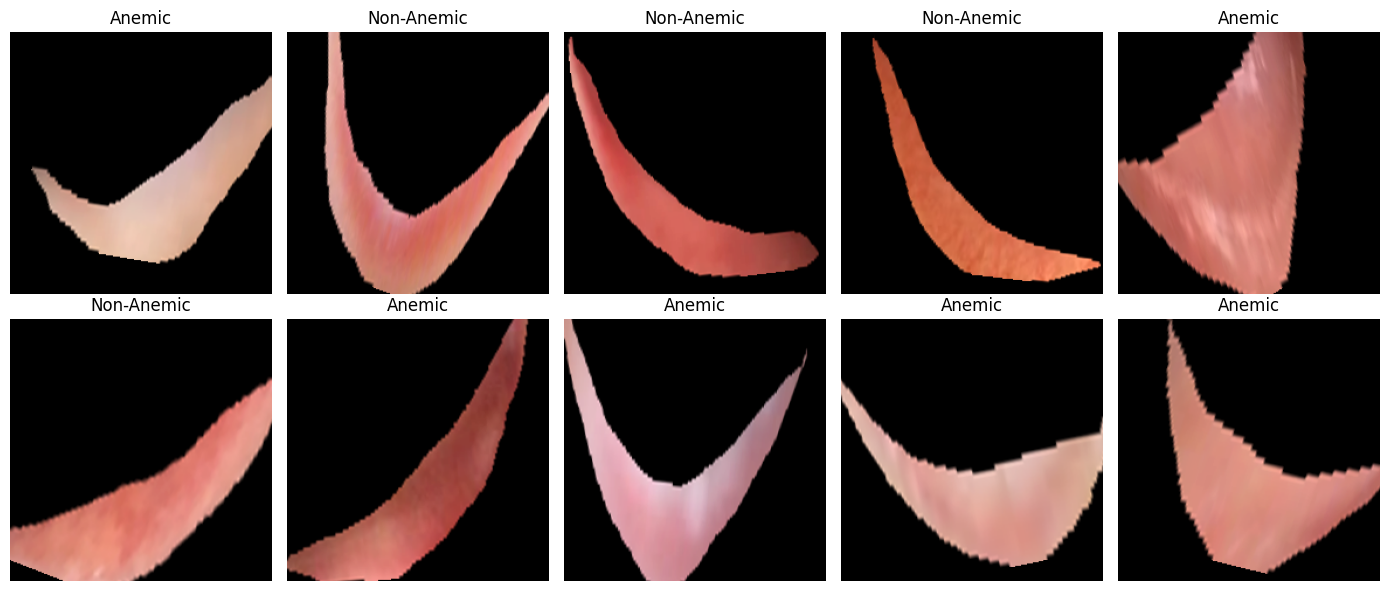

In [9]:
image_batch, label_batch = next(train_generator)

plt.figure(figsize=(14, 6))

for i in range(10):  # show first 8 images
    plt.subplot(2, 5, i + 1)
    plt.imshow(image_batch[i])
    plt.title(class_names[np.argmax(label_batch[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()


## Model 01

In [19]:
history_1 = model_1.fit(train_generator,
          batch_size =32,
          epochs = 30,
          validation_data=val_generator, 
          verbose=1)

Epoch 1/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 187s 715ms/step - accuracy: 0.5142 - loss: 0.6990 - val_accuracy: 0.5010 - val_loss: 0.6895
Epoch 2/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 134s 521ms/step - accuracy: 0.5239 - loss: 0.6918 - val_accuracy: 0.5030 - val_loss: 0.6896
Epoch 3/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 142s 551ms/step - accuracy: 0.5286 - loss: 0.6884 - val_accuracy: 0.5220 - val_loss: 0.6845
Epoch 4/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 145s 562ms/step - accuracy: 0.5583 - loss: 0.6806 - val_accuracy: 0.5320 - val_loss: 0.6781
Epoch 5/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 146s 566ms/step - accuracy: 0.5684 - loss: 0.6701 - val_accuracy: 0.5610 - val_loss: 0.6702
Epoch 6/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 146s 565ms/step - accuracy: 0.6039 - loss: 0.6560 - val_accuracy: 0.5760 - val_loss: 0.6617
Epoch 7/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 145s 562ms/step - accuracy: 0.6182 - loss: 0.6391 - val_accuracy: 0.5700 - val_loss: 0.6779
Epoch 8/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 145s 562ms/step - accuracy: 0.6371 -

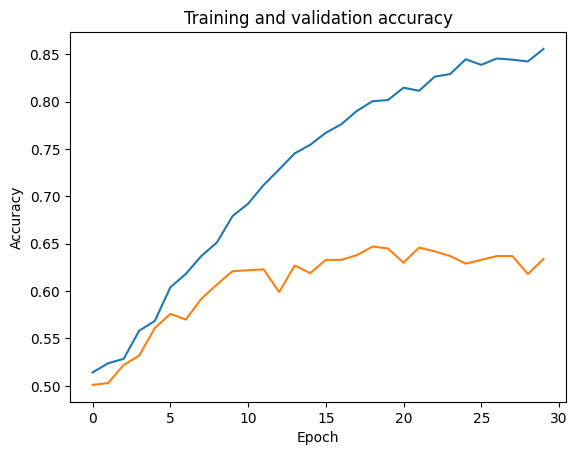

In [20]:
train_acc_1=history_1.history['accuracy']
val_acc_1= history_1.history['val_accuracy']

plt.plot(history_1.history['accuracy'])
plt.plot(history_1.history['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and validation accuracy')
plt.show()

In [21]:
print(f'Training accuracy: {train_acc_1[-1]*100:.3f}')
print (f'Validation accuracy: {val_acc_1[-1]*100:.3f}')

Training accuracy: 85.562
Validation accuracy: 63.400


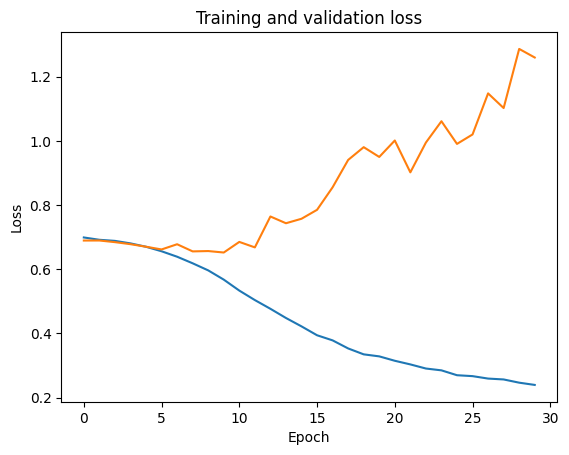

In [22]:
train_loss_1= history_1.history['loss']
val_loss_1= history_1.history['val_loss']

plt.plot(history_1.history['loss'])
plt.plot(history_1.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and validation loss')
plt.show()

In [23]:
print(f'Train loss: {train_loss_1[-1]:.3f}')
print(f'Validation loss: {val_loss_1[-1]:.3f}')

Train loss: 0.240
Validation loss: 1.260


In [24]:
test_loss_1, test_acc_1 = model_1.evaluate(test_generator)
print("Test Loss:", test_loss_1)
print("Test Accuracy:", test_acc_1)

32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 482ms/step - accuracy: 0.6830 - loss: 1.0993
Test Loss: 1.0993449687957764
Test Accuracy: 0.6830000281333923


32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step


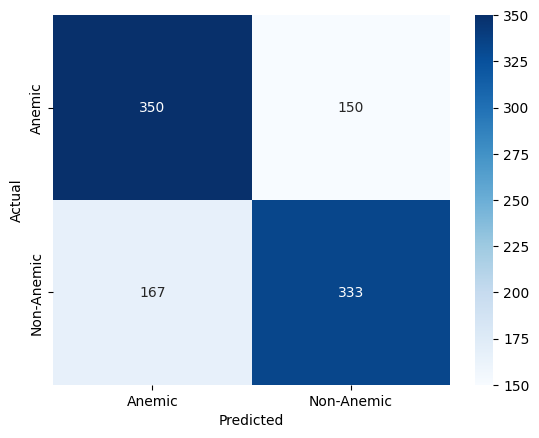

In [25]:
true_labels = test_generator.classes
predictions = model_1.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)
cm = confusion_matrix(true_labels, predicted_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [26]:
print(classification_report(true_labels, predicted_classes, target_names=class_names))

              precision    recall  f1-score   support

      Anemic       0.68      0.70      0.69       500
  Non-Anemic       0.69      0.67      0.68       500

    accuracy                           0.68      1000
   macro avg       0.68      0.68      0.68      1000
weighted avg       0.68      0.68      0.68      1000



## Model 02

In [ ]:
history_2 = model_2.fit(train_generator,
          batch_size =32,
          epochs = 30,
          validation_data=val_generator, 
          verbose=1)

c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 384s 1s/step - accuracy: 0.5336 - loss: 0.6906 - val_accuracy: 0.5000 - val_loss: 0.6940
Epoch 2/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 1405s 5s/step - accuracy: 0.5116 - loss: 0.6907 - val_accuracy: 0.5400 - val_loss: 0.7528
Epoch 3/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 193s 747ms/step - accuracy: 0.5230 - loss: 0.6893 - val_accuracy: 0.5610 - val_loss: 0.6746
Epoch 4/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 189s 731ms/step - accuracy: 0.5366 - loss: 0.6815 - val_accuracy: 0.5040 - val_loss: 0.6915
Epoch 5/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 199s 718ms/step - accuracy: 0.5355 - loss: 0.6813 - val_accuracy: 0.5180 - val_loss: 0.6803
Epoch 6/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 191s 738ms/step - accuracy: 0.5266 - loss: 0.6820 - val_accuracy: 0.5170 - val_loss: 0.6889
Epoch 7/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 186s 720ms/step - accuracy: 0.5342 - loss: 0.6860 - val_accuracy: 0.5150 - val_loss: 0.6848
Epoch 8/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 188s 727ms/step - accuracy: 0.5145 - loss

In [28]:
test_loss_2, test_acc_2 = model_2.evaluate(test_generator)
print("Test Loss:", test_loss_2)
print("Test Accuracy:", test_acc_2)

32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 491ms/step - accuracy: 0.6320 - loss: 0.6457
Test Loss: 0.6457005143165588
Test Accuracy: 0.6320000290870667


32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step


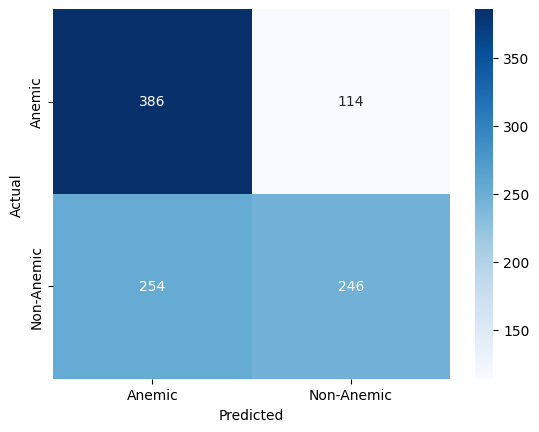

In [29]:
predictions = model_2.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)
cm = confusion_matrix(true_labels, predicted_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [30]:
print(classification_report(true_labels, predicted_classes, target_names=class_names))

              precision    recall  f1-score   support

      Anemic       0.60      0.77      0.68       500
  Non-Anemic       0.68      0.49      0.57       500

    accuracy                           0.63      1000
   macro avg       0.64      0.63      0.62      1000
weighted avg       0.64      0.63      0.62      1000



## Model 03

In [23]:
history_3 = model_3.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,                
    callbacks=[early_stop]
)

Epoch 1/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 664s 3s/step - accuracy: 0.5311 - loss: 0.7780 - val_accuracy: 0.6320 - val_loss: 0.6476
Epoch 2/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 800s 3s/step - accuracy: 0.5976 - loss: 0.6575 - val_accuracy: 0.6550 - val_loss: 0.6309
Epoch 3/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 779s 3s/step - accuracy: 0.6288 - loss: 0.6370 - val_accuracy: 0.6830 - val_loss: 0.6157
Epoch 4/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 517s 2s/step - accuracy: 0.6549 - loss: 0.6184 - val_accuracy: 0.7120 - val_loss: 0.5938
Epoch 5/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 424s 2s/step - accuracy: 0.6772 - loss: 0.6008 - val_accuracy: 0.6990 - val_loss: 0.5806
Epoch 6/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 429s 2s/step - accuracy: 0.6950 - loss: 0.5844 - val_accuracy: 0.7040 - val_loss: 0.5631
Epoch 7/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 425s 2s/step - accuracy: 0.7066 - loss: 0.5676 - val_accuracy: 0.7300 - val_loss: 0.5495
Epoch 8/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 425s 2s/step - accuracy: 0.7203 - loss: 0.5571 - val_accu

In [24]:
test_loss_3, test_acc_3 = model_3.evaluate(test_generator)
print("Test Loss:", test_loss_3)
print("Test Accuracy:", test_acc_3)

32/32 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.9000 - loss: 0.2447
Test Loss: 0.24471233785152435
Test Accuracy: 0.8999999761581421


32/32 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step


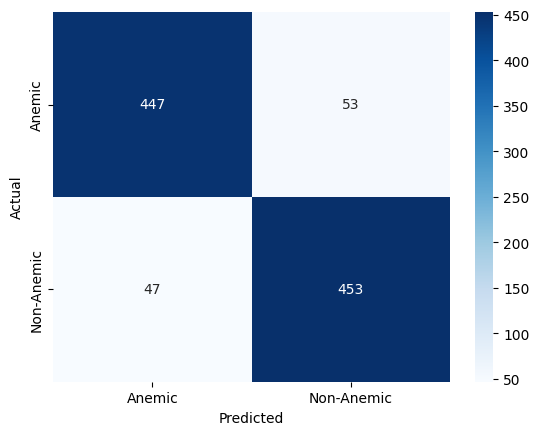

In [25]:
true_labels = test_generator.classes
predictions = model_3.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)
cm = confusion_matrix(true_labels, predicted_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [26]:
print(classification_report(true_labels, predicted_classes, target_names=class_names))

              precision    recall  f1-score   support

      Anemic       0.90      0.89      0.90       500
  Non-Anemic       0.90      0.91      0.90       500

    accuracy                           0.90      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.90      0.90      0.90      1000



## Model 04

In [37]:
history_attention = model_1_attention.fit(
    train_generator,
    batch_size=32,
    epochs=30,
    validation_data=val_generator, 
    verbose=1
)

test_loss, test_acc = model_1_attention.evaluate(test_generator)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

model_1_attention.save('model_1_attention.h5')

Epoch 1/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 216s 827ms/step - accuracy: 0.5145 - loss: 0.8791 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 2/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 175s 680ms/step - accuracy: 0.5151 - loss: 0.7003 - val_accuracy: 0.5010 - val_loss: 0.6892
Epoch 3/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 183s 708ms/step - accuracy: 0.5074 - loss: 0.7011 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 181s 700ms/step - accuracy: 0.5110 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 168s 650ms/step - accuracy: 0.5110 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 6/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 169s 657ms/step - accuracy: 0.5110 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 7/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 174s 675ms/step - accuracy: 0.5110 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 8/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 276s 1s/step - accuracy: 0.5110 - lo

Test Loss: 0.6933228373527527
Test Accuracy: 0.5


# Palm

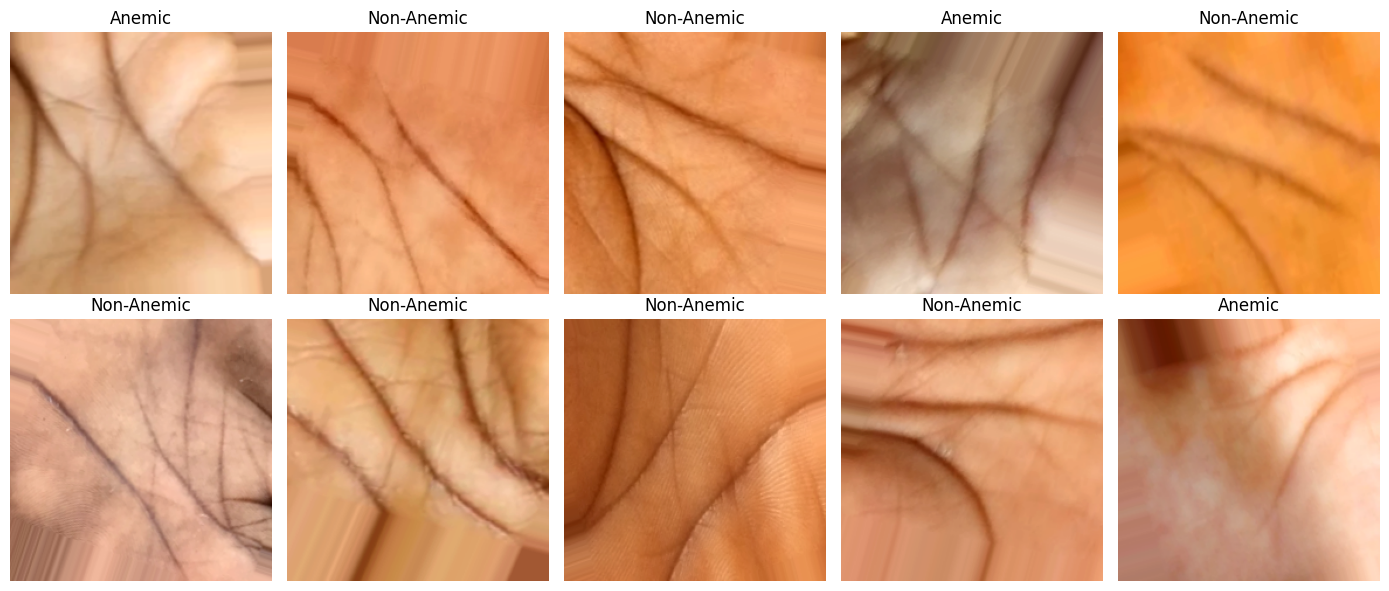

In [ ]:
image_batch, label_batch = next(train_generator_Palm)

plt.figure(figsize=(14, 6))

for i in range(10): 
    plt.subplot(2, 5, i + 1)
    plt.imshow(image_batch[i])
    plt.title(class_names[np.argmax(label_batch[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Model 1

In [36]:
history_1_Palm = model_1.fit(train_generator_Palm,
          batch_size =32,
          epochs = 30,
          validation_data=val_generator_Palm, 
          verbose=1)

Epoch 1/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 201s 773ms/step - accuracy: 0.5056 - loss: 0.7132 - val_accuracy: 0.4990 - val_loss: 0.6926
Epoch 2/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 143s 552ms/step - accuracy: 0.4977 - loss: 0.6933 - val_accuracy: 0.4990 - val_loss: 0.6925
Epoch 3/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 165s 636ms/step - accuracy: 0.5001 - loss: 0.6929 - val_accuracy: 0.5000 - val_loss: 0.6921
Epoch 4/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 179s 691ms/step - accuracy: 0.4954 - loss: 0.6925 - val_accuracy: 0.4990 - val_loss: 0.6924
Epoch 5/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 164s 631ms/step - accuracy: 0.4963 - loss: 0.6926 - val_accuracy: 0.5000 - val_loss: 0.6927
Epoch 6/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 161s 620ms/step - accuracy: 0.5024 - loss: 0.6921 - val_accuracy: 0.5010 - val_loss: 0.6913
Epoch 7/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 163s 629ms/step - accuracy: 0.5044 - loss: 0.6927 - val_accuracy: 0.4990 - val_loss: 0.6930
Epoch 8/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 162s 626ms/step - accuracy: 0.4963 -

In [37]:
test_loss_1_Palm, test_acc_1_Palm = model_1.evaluate(test_generator_Palm)
print("Test Loss:", test_loss_1_Palm)
print("Test Accuracy:", test_acc_1_Palm)

32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 591ms/step - accuracy: 0.5400 - loss: 0.6854
Test Loss: 0.6853554248809814
Test Accuracy: 0.5400000214576721


32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 161ms/step


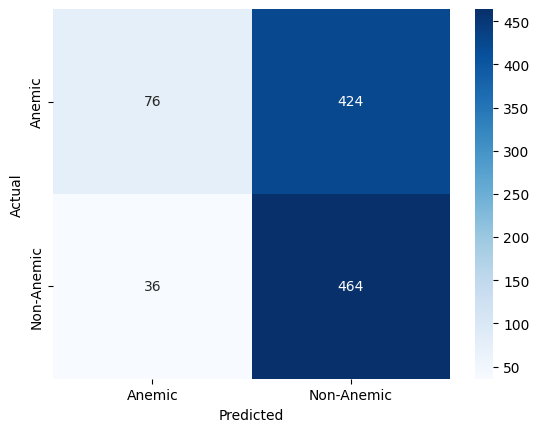

In [38]:
true_labels = test_generator_Palm.classes
predictions = model_1.predict(test_generator_Palm)
predicted_classes = np.argmax(predictions, axis=1)
cm = confusion_matrix(true_labels, predicted_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [39]:
print(classification_report(true_labels, predicted_classes, target_names=class_names))

              precision    recall  f1-score   support

      Anemic       0.68      0.15      0.25       500
  Non-Anemic       0.52      0.93      0.67       500

    accuracy                           0.54      1000
   macro avg       0.60      0.54      0.46      1000
weighted avg       0.60      0.54      0.46      1000



## Model 2

In [40]:
history_2_palm = model_2.fit(train_generator_Palm,
          batch_size =32,
          epochs = 30,
          validation_data=val_generator_Palm, 
          verbose=1)

Epoch 1/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 232s 894ms/step - accuracy: 0.5010 - loss: 0.7042 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 121s 465ms/step - accuracy: 0.5016 - loss: 0.6948 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 133s 514ms/step - accuracy: 0.4973 - loss: 0.6938 - val_accuracy: 0.4990 - val_loss: 0.6932
Epoch 4/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 133s 512ms/step - accuracy: 0.4994 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 191s 736ms/step - accuracy: 0.4996 - loss: 0.6945 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 6/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 206s 796ms/step - accuracy: 0.5068 - loss: 0.6929 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 7/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 186s 717ms/step - accuracy: 0.5044 - loss: 0.6929 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 8/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 115s 443ms/step - accuracy: 0.5051 -

In [41]:
test_loss_2_palm, test_acc_2_palm = model_2.evaluate(test_generator_Palm)
print("Test Loss:", test_loss_2_palm)
print("Test Accuracy:", test_acc_2_palm)

32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 487ms/step - accuracy: 0.5110 - loss: 0.6909
Test Loss: 0.6909176707267761
Test Accuracy: 0.5109999775886536


32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step


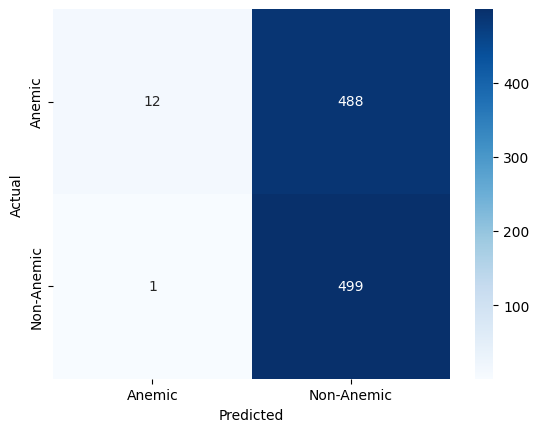

In [42]:
predictions = model_2.predict(test_generator_Palm)
predicted_classes = np.argmax(predictions, axis=1)
cm = confusion_matrix(true_labels, predicted_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [43]:
print(classification_report(true_labels, predicted_classes, target_names=class_names))

              precision    recall  f1-score   support

      Anemic       0.92      0.02      0.05       500
  Non-Anemic       0.51      1.00      0.67       500

    accuracy                           0.51      1000
   macro avg       0.71      0.51      0.36      1000
weighted avg       0.71      0.51      0.36      1000



## Model 3

In [14]:
history_3_Palm = model_3.fit(
    train_generator_Palm,
    validation_data=val_generator_Palm,
    epochs=50,                
    callbacks=[early_stop]
)

Epoch 1/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 509s 2s/step - accuracy: 0.5522 - loss: 0.7649 - val_accuracy: 0.6320 - val_loss: 0.6479
Epoch 2/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 461s 2s/step - accuracy: 0.6071 - loss: 0.6630 - val_accuracy: 0.6880 - val_loss: 0.6212
Epoch 3/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 460s 2s/step - accuracy: 0.6377 - loss: 0.6345 - val_accuracy: 0.6780 - val_loss: 0.6014
Epoch 4/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 588s 2s/step - accuracy: 0.6628 - loss: 0.6099 - val_accuracy: 0.7000 - val_loss: 0.5840
Epoch 5/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 716s 3s/step - accuracy: 0.6861 - loss: 0.5864 - val_accuracy: 0.7100 - val_loss: 0.5672
Epoch 6/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 729s 3s/step - accuracy: 0.6964 - loss: 0.5732 - val_accuracy: 0.7280 - val_loss: 0.5481
Epoch 7/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 745s 3s/step - accuracy: 0.7138 - loss: 0.5520 - val_accuracy: 0.7340 - val_loss: 0.5347
Epoch 8/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 652s 3s/step - accuracy: 0.7259 - loss: 0.5366 - val_accu

In [15]:
test_loss_3_palm, test_acc_3_palm = model_3.evaluate(test_generator_Palm)
print("Test Loss:", test_loss_3_palm)
print("Test Accuracy:", test_acc_3_palm)

32/32 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.8930 - loss: 0.2853
Test Loss: 0.28532522916793823
Test Accuracy: 0.8930000066757202


32/32 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step


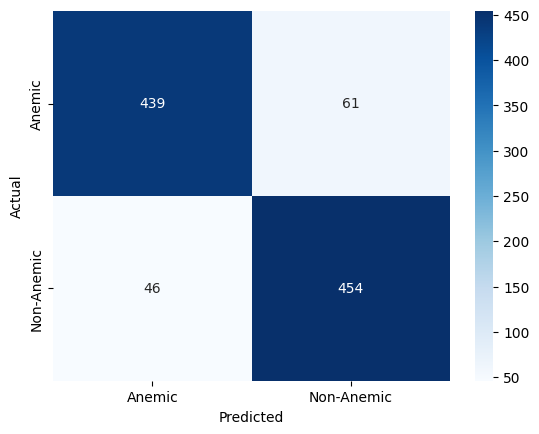

In [ ]:
true_labels = test_generator_Palm.classes
predictions_3 = model_3.predict(test_generator_Palm)
predicted_classes_3 = np.argmax(predictions_3, axis=1)
cm = confusion_matrix(true_labels, predicted_classes_3)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [19]:
print(classification_report(true_labels, predicted_classes_3, target_names=class_names))

              precision    recall  f1-score   support

      Anemic       0.91      0.88      0.89       500
  Non-Anemic       0.88      0.91      0.89       500

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000



# Nail

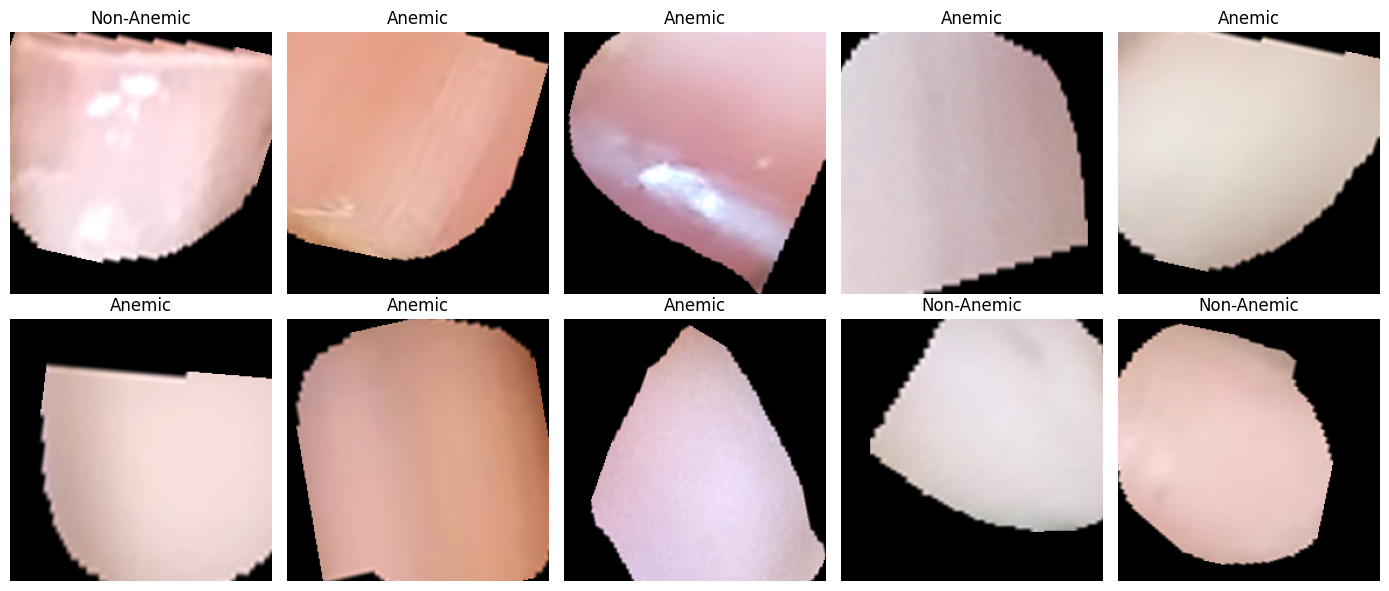

In [50]:
image_batch, label_batch = next(train_generator_nail)

plt.figure(figsize=(14, 6))

for i in range(10):  # show first 8 images
    plt.subplot(2, 5, i + 1)
    plt.imshow(image_batch[i])
    plt.title(class_names[np.argmax(label_batch[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()


## Model 1

In [54]:
history_1_nail = model_1.fit(train_generator_nail,
          batch_size =32,
          epochs = 30,
          validation_data=val_generator_nail, 
          verbose=1)

Epoch 1/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 197s 742ms/step - accuracy: 0.5103 - loss: 0.7001 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 2/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 141s 536ms/step - accuracy: 0.5134 - loss: 0.6938 - val_accuracy: 0.5010 - val_loss: 0.6933
Epoch 3/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 149s 567ms/step - accuracy: 0.5138 - loss: 0.6942 - val_accuracy: 0.5000 - val_loss: 0.7152
Epoch 4/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 149s 567ms/step - accuracy: 0.5227 - loss: 0.6915 - val_accuracy: 0.5020 - val_loss: 0.6940
Epoch 5/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 148s 564ms/step - accuracy: 0.5292 - loss: 0.6896 - val_accuracy: 0.5060 - val_loss: 0.6956
Epoch 6/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 148s 561ms/step - accuracy: 0.5462 - loss: 0.6855 - val_accuracy: 0.5130 - val_loss: 0.7013
Epoch 7/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 148s 561ms/step - accuracy: 0.5696 - loss: 0.6771 - val_accuracy: 0.4920 - val_loss: 0.7071
Epoch 8/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 148s 564ms/step - accuracy: 0.5964 -

In [55]:
test_loss_1_nail, test_acc_1_nail = model_1.evaluate(test_generator_nail)
print("Test Loss:", test_loss_1_nail)
print("Test Accuracy:", test_acc_1_nail)

32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 493ms/step - accuracy: 0.5080 - loss: 2.8942
Test Loss: 2.894221305847168
Test Accuracy: 0.5080000162124634


32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step


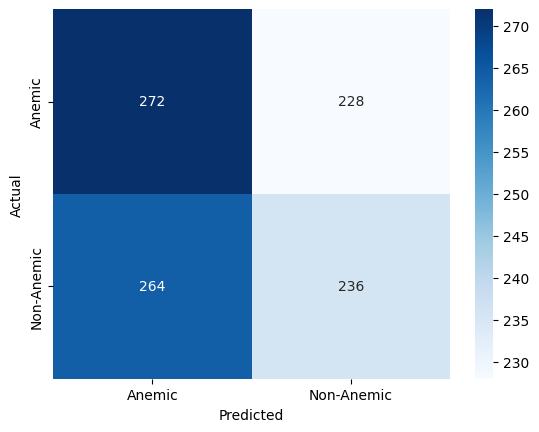

In [56]:
true_labels = test_generator_nail.classes
predictions = model_1.predict(test_generator_nail)
predicted_classes = np.argmax(predictions, axis=1)
cm = confusion_matrix(true_labels, predicted_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [57]:
print(classification_report(true_labels, predicted_classes, target_names=class_names))

              precision    recall  f1-score   support

      Anemic       0.51      0.54      0.53       500
  Non-Anemic       0.51      0.47      0.49       500

    accuracy                           0.51      1000
   macro avg       0.51      0.51      0.51      1000
weighted avg       0.51      0.51      0.51      1000



## Model 2

In [58]:
history_2_nail = model_2.fit(train_generator_nail,
          batch_size =32,
          epochs = 30,
          validation_data=val_generator_nail, 
          verbose=1)

Epoch 1/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 110s 420ms/step - accuracy: 0.5055 - loss: 0.7686 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 2/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 111s 424ms/step - accuracy: 0.5132 - loss: 0.6929 - val_accuracy: 0.5000 - val_loss: 0.6935
Epoch 3/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 111s 424ms/step - accuracy: 0.5132 - loss: 0.6928 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 4/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 110s 418ms/step - accuracy: 0.5132 - loss: 0.6929 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 5/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 111s 421ms/step - accuracy: 0.5132 - loss: 0.6929 - val_accuracy: 0.5000 - val_loss: 0.6935
Epoch 6/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 113s 431ms/step - accuracy: 0.5132 - loss: 0.6929 - val_accuracy: 0.5000 - val_loss: 0.6936
Epoch 7/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 111s 423ms/step - accuracy: 0.5132 - loss: 0.6929 - val_accuracy: 0.5000 - val_loss: 0.6936
Epoch 8/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 111s 424ms/step - accuracy: 0.5132 -

In [59]:
test_loss_2_nail, test_acc_2_nail = model_2.evaluate(test_generator_nail)
print("Test Loss:", test_loss_2_nail)
print("Test Accuracy:", test_acc_2_nail)

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 127ms/step - accuracy: 0.5000 - loss: 0.6935
Test Loss: 0.6935433745384216
Test Accuracy: 0.5


32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step


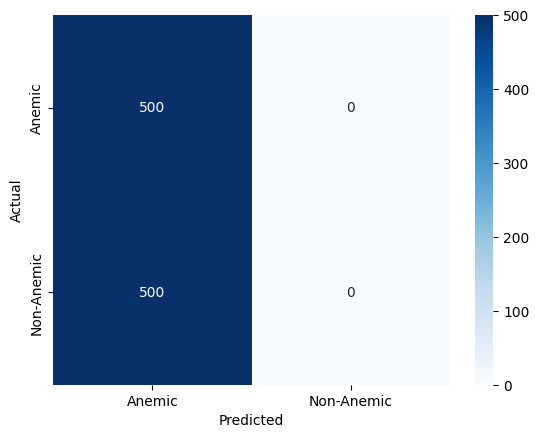

In [60]:
predictions = model_2.predict(test_generator_nail)
predicted_classes = np.argmax(predictions, axis=1)
cm = confusion_matrix(true_labels, predicted_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [61]:
print(classification_report(true_labels, predicted_classes, target_names=class_names))

              precision    recall  f1-score   support

      Anemic       0.50      1.00      0.67       500
  Non-Anemic       0.00      0.00      0.00       500

    accuracy                           0.50      1000
   macro avg       0.25      0.50      0.33      1000
weighted avg       0.25      0.50      0.33      1000



c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

## Model 3

In [23]:
history_3_nail = model_3.fit(
    train_generator_nail,
    validation_data=val_generator_nail,
    epochs=50,                
    callbacks=[early_stop]
)

Epoch 1/50
263/263 ━━━━━━━━━━━━━━━━━━━━ 486s 2s/step - accuracy: 0.5146 - loss: 0.8373 - val_accuracy: 0.5230 - val_loss: 0.6949
Epoch 2/50
263/263 ━━━━━━━━━━━━━━━━━━━━ 454s 2s/step - accuracy: 0.5281 - loss: 0.6906 - val_accuracy: 0.5470 - val_loss: 0.6915
Epoch 3/50
263/263 ━━━━━━━━━━━━━━━━━━━━ 559s 2s/step - accuracy: 0.5433 - loss: 0.6834 - val_accuracy: 0.5300 - val_loss: 0.6880
Epoch 4/50
263/263 ━━━━━━━━━━━━━━━━━━━━ 449s 2s/step - accuracy: 0.5470 - loss: 0.6809 - val_accuracy: 0.5550 - val_loss: 0.6835
Epoch 5/50
263/263 ━━━━━━━━━━━━━━━━━━━━ 665s 3s/step - accuracy: 0.5633 - loss: 0.6738 - val_accuracy: 0.5720 - val_loss: 0.6787


In [24]:
test_loss_3_nail, test_acc_3_nail = model_3.evaluate(test_generator_nail)
print("Test Loss:", test_loss_3_nail)
print("Test Accuracy:", test_acc_3_nail)

32/32 ━━━━━━━━━━━━━━━━━━━━ 85s 3s/step - accuracy: 0.5320 - loss: 0.6931
Test Loss: 0.693058431148529
Test Accuracy: 0.5320000052452087


32/32 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step


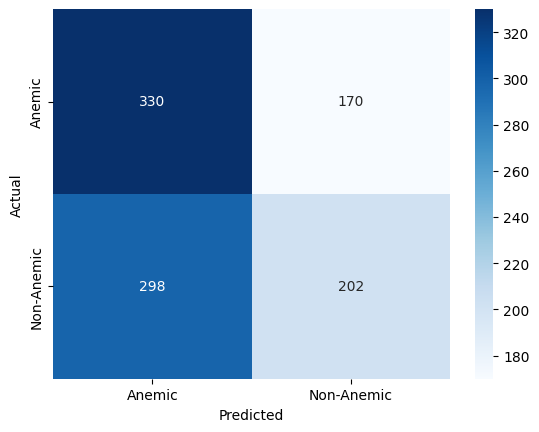

In [ ]:
true_labels = test_generator_nail.classes
predictions = model_3.predict(test_generator_nail)
predicted_classes = np.argmax(predictions, axis=1)
cm = confusion_matrix(true_labels, predicted_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [26]:
print(classification_report(true_labels, predicted_classes, target_names=class_names))

              precision    recall  f1-score   support

      Anemic       0.53      0.66      0.59       500
  Non-Anemic       0.54      0.40      0.46       500

    accuracy                           0.53      1000
   macro avg       0.53      0.53      0.52      1000
weighted avg       0.53      0.53      0.52      1000



# Self Attention / Cross Attention / Final Model

In [110]:
input_layer = Input(shape=(224, 224, 3))

densenet = model_3.layers[0]
pooling = model_3.layers[1]

features = densenet(input_layer)
features = pooling(features)

feature_extractor = Model(inputs=input_layer, outputs=features, name='feature_extractor')
feature_extractor.trainable = False
feature_dim = 1024
print(f"Feature extractor output shape: {feature_extractor.output_shape}")

Feature extractor output shape: (None, 1024)


In [111]:
input_conj = layers.Input(shape=(224,224,3))
input_palm = layers.Input(shape=(224,224,3))
input_nail = layers.Input(shape=(224,224,3))

In [112]:
f_conj = feature_extractor(input_conj)
f_palm = feature_extractor(input_palm)
f_nail = feature_extractor(input_nail)

In [113]:
f_conj = layers.Reshape((1, feature_dim))(f_conj)
f_palm = layers.Reshape((1, feature_dim))(f_palm)
f_nail = layers.Reshape((1, feature_dim))(f_nail)

In [114]:
f_conj_att = SelfAttention(feature_dim)(f_conj)
f_palm_att = SelfAttention(feature_dim)(f_palm)
f_nail_att = SelfAttention(feature_dim)(f_nail)

In [118]:
f_conj_cross1 = CrossAttention(feature_dim)(f_conj_att, f_palm_att)
f_conj_cross2 = CrossAttention(feature_dim)(f_conj_att, f_nail_att)
f_conj_final = layers.Concatenate(axis=-1)([f_conj_cross1, f_conj_cross2])

In [119]:
f_palm_cross1 = CrossAttention(feature_dim)(f_palm_att, f_conj_att)
f_palm_cross2 = CrossAttention(feature_dim)(f_palm_att, f_nail_att)
f_palm_final = layers.Concatenate()([f_palm_cross1, f_palm_cross2])

In [120]:
f_nail_cross1 = CrossAttention(feature_dim)(f_nail_att, f_conj_att)
f_nail_cross2 = CrossAttention(feature_dim)(f_nail_att, f_palm_att)
f_nail_final = layers.Concatenate()([f_nail_cross1, f_nail_cross2])

In [121]:
f_conj_final = layers.Flatten()(f_conj_final)
f_palm_final = layers.Flatten()(f_palm_final)
f_nail_final = layers.Flatten()(f_nail_final)

In [122]:
fused = layers.Concatenate()([f_conj_final, f_palm_final, f_nail_final])

fused = layers.Dense(256, activation='relu')(fused)
fused = layers.Dropout(0.5)(fused)
fused= layers.Dense(128, activation='relu')(fused)
fused = layers.Dropout(0.3)(fused)
output = layers.Dense(2, activation='softmax')(fused)

In [123]:
final_model = Model(
    inputs=[input_conj, input_palm, input_nail], 
    outputs=output,
    name='multimodal_anemia_detection'
)

In [124]:
final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

final_model.summary()

Model: "multimodal_anemia_detection"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_17      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_18      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_19      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_extractor   │ (None, 1024)      │  7,037,504 │ input_layer_17[0… │
│ (Functional)        │                   │            │ input_layer_18[0… │
│                     │                   │            │ input_layer_19[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_9 (Reshape) │ (None, 1, 1024)   │          0 │ feature_extracto… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_10          │ (None, 1, 1024)   │          0 │ feature_extracto… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_11          │ (None, 1, 1024)   │          0 │ feature_extracto… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention_11   │ (None, 1, 1024)   │  3,148,800 │ reshape_9[0][0]   │
│ (SelfAttention)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention_12   │ (None, 1, 1024)   │  3,148,800 │ reshape_10[0][0]  │
│ (SelfAttention)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention_13   │ (None, 1, 1024)   │  3,148,800 │ reshape_11[0][0]  │
│ (SelfAttention)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cross_attention_17  │ (None, 1, 1024)   │  3,148,800 │ self_attention_1… │
│ (CrossAttention)    │                   │            │ self_attention_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cross_attention_18  │ (None, 1, 1024)   │  3,148,800 │ self_attention_1… │
│ (CrossAttention)    │                   │            │ self_attention_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cross_attention_19  │ (None, 1, 1024)   │  3,148,800 │ self_attention_1… │
│ (CrossAttention)    │                   │            │ self_attention_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cross_attention_20  │ (None, 1, 1024)   │  3,148,800 │ self_attention_1… │
│ (CrossAttention)    │                   │            │ self_attention_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cross_attention_21  │ (None, 1, 1024)   │  3,148,800 │ self_attention_1… │
│ (CrossAttention)    │                   │            │ self_attention_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cross_attention_22  │ (None, 1, 1024)   │  3,148,800 │ self_attention_1… │
│ (CrossAttention)    │                   │            │ self_attention_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 1, 2048)   │          0 │ cross_attention_

 Total params: 36,982,978 (141.08 MB)

 Trainable params: 29,945,474 (114.23 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [19]:
model = tf.keras.models.load_model("Models\model_3.h5")

<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
C:\Users\admin\AppData\Local\Temp\ipykernel_11008\4002523254.py:1: SyntaxWarning: invalid escape sequence '\m'
  model = tf.keras.models.load_model("Models\model_3.h5")


In [44]:
image_Paths = [
    (r'Dataset\Conjunctiva-1\Anemic\Anemic-001 (2).png','Anemic'),
    (r'Dataset\Conjunctiva-1\Non-Anemic\Non-Anemic-002 (4).png', 'Non-Anemic'),
    (r'Dataset\Nail\Anemic\Anemic-Fin-007 (2).png','Anemic'),
    (r'Dataset\Nail\Non-Anemic\Non-anemic-Fin-010.png', 'Non-Anemic')

]

In [23]:
def predict(model, img_path, img_size=(224, 224)):
    img = tf.keras.preprocessing.image.load_img(
        img_path, target_size=img_size
    )

    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = tf.expand_dims(img_array, axis=0)
    
    predictions = model.predict(img_array, verbose=0)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * np.max(predictions[0]), 2)

    return predicted_class, confidence, img


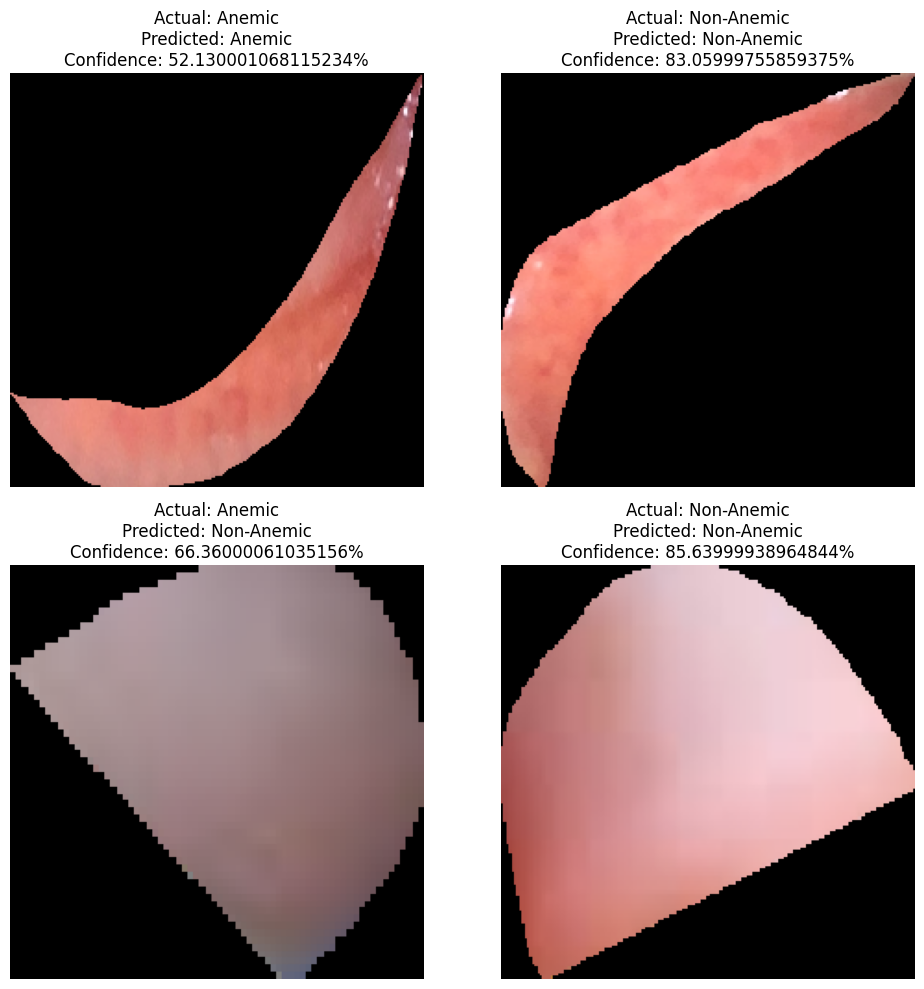

In [47]:
plt.figure(figsize=(10, 10))

for i, (img_path, actual_class) in enumerate(image_Paths):
    ax = plt.subplot(2, 2, i + 1)

    predicted_class, confidence, img = predict(model, img_path)

    plt.imshow(img)
    plt.title(
        f"Actual: {actual_class}\n"
        f"Predicted: {predicted_class}\n"
        f"Confidence: {confidence}%"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()



# Dual Head